
<br>
<font>
<div dir=ltr align=center>
<img src="https://cdn.freebiesupply.com/logos/large/2x/sharif-logo-png-transparent.png" width=150 height=150>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Artificial Intelligence <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Spring 2025<br>
<font color=3C99D size=5>
    Project-Phase2<br>
    Soft Actor Critic<br>
<font color=696880 size=4>
    Ali Najar-Mohmmad Shafizade-Armin Khosravi




In this notebook, we are going to get familiar with SAC algorithm. Soft Actor Critic (SAC) is an off-policy algorithm that maximizes a combination of expected return **and** entropy. Higher entropy results in higher exploration, which is an important concept in Reinforcement Learning.

## 📦 Setup and Dependencies

Install PyBullet for Physics based environments.

In [21]:
!pip install -q pybullet Box2D
!nvidia-smi

Thu Aug 14 20:52:56 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             36W /   70W |     178MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Import necessary packages.

In [22]:
import os
import numpy as np
import torch as T
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.distributions import Normal

import warnings
warnings.filterwarnings('ignore')
from gym.wrappers import RecordVideo
import gym
import pybullet_envs
np.bool8 = np.bool_
from tqdm.notebook import trange
from IPython.display import Video

## 📈 Utility codes

We will use this utility function to visualize the training progress.

In [23]:
def plot_learning_curve(x, filename, save_plot=True):
    avg_x = [np.mean(x[np.max([0, i - 100]):i]) for i in range(len(x))]
    plt.figure(dpi=200)
    plt.title('Learning Curve')
    plt.plot(range(len(x)), x, label='score', alpha=0.3)
    plt.plot(range(len(avg_x)), avg_x, label='average score')
    plt.xlabel('Episode')
    plt.ylabel('Score')
    plt.legend()
    plt.grid()
    if save_plot:
        plt.savefig(filename + '.png')
    plt.show()

This class implements a **Replay Buffer** to store and sample transitions of the form $(s_t, a_t, r_t, s_{t+1}, d_t)$ to break correlation in updates for stability in mini-batch stochastic gradient descent.


In [24]:
class ReplayBuffer:
    def __init__(self, buffer_size, state_dims, action_dims):
        self.buffer_size = buffer_size
        self.ptr = 0
        self.is_full = False

        # Initialize buffers
        self.states = np.zeros((buffer_size, *state_dims), dtype=np.float32)
        self.next_states = np.zeros((buffer_size, *state_dims), dtype=np.float32)
        self.actions = np.zeros((buffer_size, *action_dims), dtype=np.float32)
        self.rewards = np.zeros(buffer_size, dtype=np.float32)
        self.dones = np.zeros(buffer_size, dtype=np.float32)

    def store_transition(self, state, action, reward, state_, done):
        self.states[self.ptr] = state
        self.actions[self.ptr] = action
        self.rewards[self.ptr] = reward
        self.next_states[self.ptr] = state_
        self.dones[self.ptr] = done

        self.ptr += 1
        if self.ptr >= self.buffer_size:
            self.ptr = 0
            self.is_full = True

    def load_batch(self, batch_size):
        max_mem = self.buffer_size if self.is_full else self.ptr
        batch_indices = np.random.choice(max_mem, batch_size, replace=False)

        states = T.tensor(self.states[batch_indices]).float()
        actions = T.tensor(self.actions[batch_indices]).float()
        rewards = T.tensor(self.rewards[batch_indices]).float().unsqueeze(1)
        states_ = T.tensor(self.next_states[batch_indices]).float()
        done = T.tensor(self.dones[batch_indices]).float().unsqueeze(1)

        return states, actions, rewards, states_, done


## 🧱 Neural Networks

This cell defines three core neural networks used in SAC:

- **Critic Network:**
Estimates the **Q-value function** $ Q(s, a) $. Two critics are used to mitigate overestimation bias.

- **Value Network:**
Estimates the **state value function** $ V(s) $, used to train the actor and as a baseline.

- **Actor Network:**
Outputs the **mean** and **standard deviation** for a Gaussian policy
$
\pi(a|s) = \mathcal{N}(\mu(s), \sigma(s))
$.

In [25]:
device = T.device('cuda' if T.cuda.is_available() else 'cpu')


class Critic(nn.Module):
    def __init__(self, beta, state_dims, action_dims, fc1_dims, fc2_dims,
                 name='Critic', ckpt_dir='tmp'):
        super(Critic, self).__init__()
        # Save args
        self.state_dims = state_dims
        self.action_dims = action_dims
        self.fc1_dims = fc1_dims
        self.fc2_dims = fc2_dims
        self.name = name
        self.ckpt_dir = ckpt_dir
        self.ckpt_path = os.path.join(ckpt_dir, name + '.pth')

        # Define layers
        self.fc1 = nn.Linear(state_dims[0] + action_dims[0], fc1_dims)
        self.fc2 = nn.Linear(fc1_dims, fc2_dims)
        self.q = nn.Linear(fc2_dims, 1)

        # Optimizer
        self.optimizer = optim.Adam(self.parameters(), lr=beta)
        self.to(device)

    def forward(self, state, action):
        x = T.cat([state, action], dim=1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        q = self.q(x)
        return q

    def save_checkpoint(self):
        T.save(self.state_dict(), self.ckpt_path)

    def load_checkpoint(self, gpu_to_cpu=False):
        if gpu_to_cpu:
            self.load_state_dict(T.load(self.ckpt_path, map_location=lambda storage, loc: storage))
        else:
            self.load_state_dict(T.load(self.ckpt_path))


class Actor(nn.Module):
    def __init__(self, alpha, state_dims, action_dims, fc1_dims, fc2_dims,
                 max_action, reparam_noise, name='Actor', ckpt_dir='tmp'):
        super(Actor, self).__init__()
        # Save args
        self.state_dims = state_dims
        self.action_dims = action_dims
        self.fc1_dims = fc1_dims
        self.fc2_dims = fc2_dims
        self.max_action = max_action
        self.reparam_noise = reparam_noise
        self.name = name
        self.ckpt_dir = ckpt_dir
        self.ckpt_path = os.path.join(ckpt_dir, name + '.pth')

        # Layers
        self.fc1 = nn.Linear(state_dims[0], fc1_dims)
        self.fc2 = nn.Linear(fc1_dims, fc2_dims)
        self.mu = nn.Linear(fc2_dims, action_dims[0])
        self.sigma = nn.Linear(fc2_dims, action_dims[0])

        # Optimizer
        self.optimizer = optim.Adam(self.parameters(), lr=alpha)
        self.to(device)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        mu = self.mu(x)
        sigma = F.softplus(self.sigma(x)) + 1e-5  # Ensure positivity
        return mu, sigma

    def sample_normal(self, state, reparameterize=True):
        mu, sigma = self.forward(state)
        dist = Normal(mu, sigma)
        if reparameterize:
            action = dist.rsample()  # reparameterization trick
        else:
            action = dist.sample()
        log_probs = dist.log_prob(action).sum(dim=1, keepdim=True)
        action = T.tanh(action) * self.max_action
        return action, log_probs

    def save_checkpoint(self):
        T.save(self.state_dict(), self.ckpt_path)

    def load_checkpoint(self, gpu_to_cpu=False):
        if gpu_to_cpu:
            self.load_state_dict(T.load(self.ckpt_path, map_location=lambda storage, loc: storage))
        else:
            self.load_state_dict(T.load(self.ckpt_path))


class Value(nn.Module):
    def __init__(self, beta, state_dims, fc1_dims, fc2_dims,
                 name='Value', ckpt_dir='tmp'):
        super(Value, self).__init__()
        # Save args
        self.state_dims = state_dims
        self.fc1_dims = fc1_dims
        self.fc2_dims = fc2_dims
        self.name = name
        self.ckpt_dir = ckpt_dir
        self.ckpt_path = os.path.join(ckpt_dir, name + '.pth')

        # Layers
        self.fc1 = nn.Linear(state_dims[0], fc1_dims)
        self.fc2 = nn.Linear(fc1_dims, fc2_dims)
        self.v = nn.Linear(fc2_dims, 1)

        # Optimizer
        self.optimizer = optim.Adam(self.parameters(), lr=beta)
        self.to(device)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        v = self.v(x)
        return v

    def save_checkpoint(self):
        T.save(self.state_dict(), self.ckpt_path)

    def load_checkpoint(self, gpu_to_cpu=False):
        if gpu_to_cpu:
            self.load_state_dict(T.load(self.ckpt_path, map_location=lambda storage, loc: storage))
        else:
            self.load_state_dict(T.load(self.ckpt_path))


## 🤖 Agent Implementation

This class encapsulates the full logic of the SAC agent. In general, the learning process uses entropy-regularized policy gradients $J_\pi = \mathbb{E}_{s_t \sim D, a_t \sim \pi} \left[ \alpha \log(\pi(a_t|s_t)) - Q(s_t, a_t) \right]$ with soft target updates $\theta_{\text{target}} \leftarrow \tau \theta + (1 - \tau)\theta_{\text{target}}$.

In [26]:
class Agent:
    def __init__(self, gamma, alpha, beta, state_dims, action_dims, max_action,
                 fc1_dim, fc2_dim, memory_size, batch_size, tau, update_period,
                 reward_scale, warmup, reparam_noise_lim, name, ckpt_dir='tmp'):

        # --- Hyperparameters ---
        self.gamma = gamma
        self.alpha = alpha
        self.beta = beta
        self.state_dims = state_dims
        self.action_dims = action_dims
        self.max_action = max_action
        self.fc1_dim = fc1_dim
        self.fc2_dim = fc2_dim
        self.memory_size = memory_size
        self.batch_size = batch_size
        self.tau = tau
        self.update_period = update_period
        self.reward_scale = reward_scale
        self.warmup = warmup
        self.reparam_noise_lim = reparam_noise_lim
        self.ckpt_dir = ckpt_dir

        model_name = f'{name}__gamma_{gamma}__alpha_{alpha}__beta_{beta}__fc1_{fc1_dim}__fc2_{fc2_dim}__bs_{batch_size}__buffer_{memory_size}__update_period_{update_period}__tau_{tau}__'
        self.model_name = model_name
        self.full_path = os.path.join(self.ckpt_dir, self.model_name)
        self.learn_iter = 0

        # --- Replay buffer ---
        self.memory = ReplayBuffer(memory_size, state_dims, action_dims)

        # --- Actor and Critic networks ---
        self.actor = Actor(alpha, state_dims, action_dims, fc1_dim, fc2_dim,
                           max_action, reparam_noise_lim, name='actor', ckpt_dir=ckpt_dir)
        self.critic_1 = Critic(beta, state_dims, action_dims, fc1_dim, fc2_dim,
                               name='critic_1', ckpt_dir=ckpt_dir)
        self.critic_2 = Critic(beta, state_dims, action_dims, fc1_dim, fc2_dim,
                               name='critic_2', ckpt_dir=ckpt_dir)

        # --- Value and target value networks ---
        self.value = Value(beta, state_dims, fc1_dim, fc2_dim, name='value', ckpt_dir=ckpt_dir)
        self.target_value = Value(beta, state_dims, fc1_dim, fc2_dim, name='target_value', ckpt_dir=ckpt_dir)

        # --- Sync target network initially ---
        self.update_target_network(tau=1.0)

    # --- Action selection ---
    def choose_action(self, state, deterministic=False, reparameterize=False):
        state = T.tensor(state, dtype=T.float32).unsqueeze(0).to(device)
        action, _ = self.actor.sample_normal(state, reparameterize=reparameterize)
        return action.cpu().detach().numpy()[0]

    # --- Store transition in replay buffer ---
    def store_transition(self, state, action, reward, state_, done):
        self.memory.store_transition(state, action, reward, state_, done)

    # --- Sample batch from replay buffer ---
    def load_batch(self):
        return self.memory.load_batch(self.batch_size)

    # --- Soft update target network ---
    def update_target_network(self, tau=None):
        tau = self.tau if tau is None else tau
        for target_param, param in zip(self.target_value.parameters(), self.value.parameters()):
            target_param.data.copy_(tau * param.data + (1 - tau) * target_param.data)

    # --- Learning step ---
    def learn(self):
        if self.memory.ptr < self.warmup:
            return  # Skip learning until enough samples collected

        states, actions, rewards, states_, dones = self.load_batch()
        states = states.to(device)
        actions = actions.to(device)
        rewards = rewards.to(device)
        states_ = states_.to(device)
        dones = dones.to(device)

        # ---------------- VALUE LOSS ----------------
        # Sample action from actor
        sampled_actions, log_probs = self.actor.sample_normal(states, reparameterize=True)

        # Estimate Q-values
        q1_val = self.critic_1(states, sampled_actions)
        q2_val = self.critic_2(states, sampled_actions)
        min_q = T.min(q1_val, q2_val)

        # Target value
        target_v = min_q - self.alpha * log_probs
        v = self.value(states)
        value_loss = F.mse_loss(v, target_v.detach())
        self.value.optimizer.zero_grad()
        value_loss.backward()
        self.value.optimizer.step()

        # ---------------- ACTOR LOSS ----------------
        new_actions, log_probs = self.actor.sample_normal(states, reparameterize=True)
        q1_new = self.critic_1(states, new_actions)
        q2_new = self.critic_2(states, new_actions)
        min_q_new = T.min(q1_new, q2_new)
        actor_loss = (self.alpha * log_probs - min_q_new).mean()
        self.actor.optimizer.zero_grad()
        actor_loss.backward()
        self.actor.optimizer.step()

        # ---------------- CRITIC LOSS ----------------
        # Compute Q target
        with T.no_grad():
            v_next = self.target_value(states_)
            q_target = self.reward_scale * rewards + self.gamma * (1 - dones) * v_next

        q1_current = self.critic_1(states, actions)
        q2_current = self.critic_2(states, actions)
        critic_1_loss = F.mse_loss(q1_current, q_target)
        critic_2_loss = F.mse_loss(q2_current, q_target)

        self.critic_1.optimizer.zero_grad()
        critic_1_loss.backward()
        self.critic_1.optimizer.step()

        self.critic_2.optimizer.zero_grad()
        critic_2_loss.backward()
        self.critic_2.optimizer.step()

        # ---------------- TARGET NETWORK UPDATE ----------------
        if self.learn_iter % self.update_period == 0:
            self.update_target_network()

        # Increment learning iteration counter
        self.learn_iter += 1
    def save_model(self):
        print('... saving checkpoint ...')
        self.actor.save_checkpoint()
        self.critic_1.save_checkpoint()
        self.critic_2.save_checkpoint()
        self.value.save_checkpoint()
        self.target_value.save_checkpoint()

    def load_model(self, gpu_to_cpu=False):
        print('... loading checkpoint ...')
        self.actor.load_checkpoint(gpu_to_cpu=gpu_to_cpu)
        self.critic_1.load_checkpoint(gpu_to_cpu=gpu_to_cpu)
        self.critic_2.load_checkpoint(gpu_to_cpu=gpu_to_cpu)
        self.value.load_checkpoint(gpu_to_cpu=gpu_to_cpu)
        self.target_value.load_checkpoint(gpu_to_cpu=gpu_to_cpu)



## ⚙️ Training Configuration

Set up your training parameters. `HalfCheetahBulletEnv-v0` is a continuous control task where the agent must learn to run using articulated legs.


In [27]:
# --- Configuration parameters ---
env_name = 'HalfCheetahBulletEnv-v0'
dir = 'tmp'
n_games = 500  # Number of episodes to train

gamma = 0.99
alpha = 3e-4
beta = 3e-4
fc1_dim = 256
fc2_dim = 256
memory_size = 1000000
batch_size = 256
tau = 0.005
update_period = 2
reward_scale = 2.0
warmup = 1000
reparam_noise_lim = 1e-6
record_video = True


## 🚀 Training Loop

For each episode, interact with the environment to collect transitions, then update the SAC networks and save the best model.

After training, a learning curve is plotted to visualize convergence and performance stability.

  0%|          | 0/500 [00:00<?, ?it/s]

... saving checkpoint ...
| Game:    1 | Score:   -1141.94 | Best score:   -1141.94 | Avg score   -1141.94 | Learning iter:      1 |
| Game:    2 | Score:   -1457.39 | Best score:   -1141.94 | Avg score   -1299.67 | Learning iter:   1001 |
| Game:    3 | Score:   -1499.36 | Best score:   -1141.94 | Avg score   -1366.23 | Learning iter:   2001 |
| Game:    4 | Score:   -1385.27 | Best score:   -1141.94 | Avg score   -1370.99 | Learning iter:   3001 |
| Game:    5 | Score:    -981.94 | Best score:   -1141.94 | Avg score   -1293.18 | Learning iter:   4001 |
... saving checkpoint ...
| Game:    6 | Score:    -216.31 | Best score:   -1113.70 | Avg score   -1113.70 | Learning iter:   5001 |
... saving checkpoint ...
| Game:    7 | Score:    -173.19 | Best score:    -979.34 | Avg score    -979.34 | Learning iter:   6001 |
... saving checkpoint ...
| Game:    8 | Score:     336.37 | Best score:    -814.88 | Avg score    -814.88 | Learning iter:   7001 |
... saving checkpoint ...
| Game:    9 |

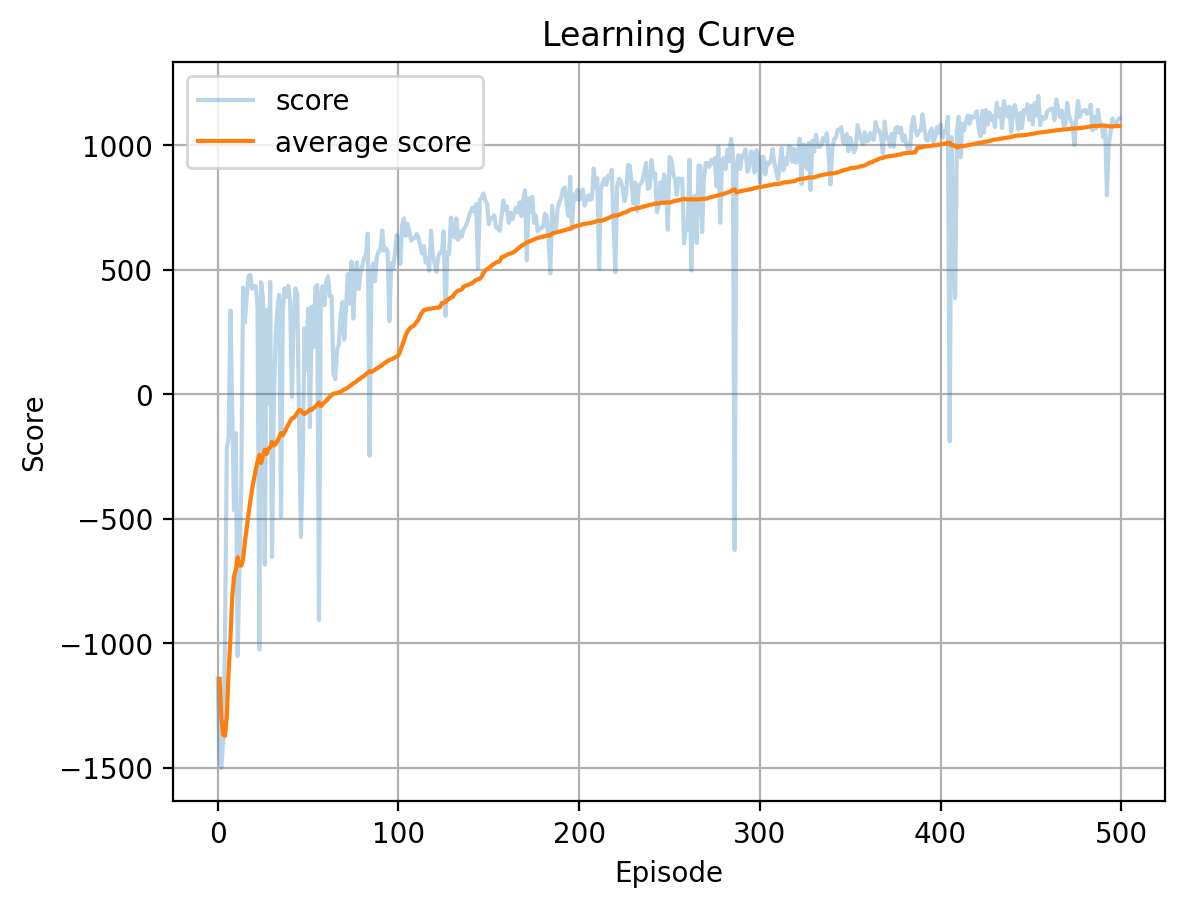

In [28]:
env = gym.make(env_name)
dir_path = os.path.join(dir, env_name)
os.makedirs(dir_path, exist_ok=True)

if record_video:
    env = RecordVideo(env, video_folder=os.path.join(dir_path, 'videos'),
                      episode_trigger=lambda ep: ep == n_games - 1)

# --- Agent initialization ---
state_dims = env.observation_space.shape
action_dims = env.action_space.shape
max_action = env.action_space.high[0]

agent = Agent(gamma=gamma, alpha=alpha, beta=beta,
              state_dims=state_dims, action_dims=action_dims,
              max_action=max_action,
              fc1_dim=fc1_dim, fc2_dim=fc2_dim,
              memory_size=memory_size, batch_size=batch_size,
              tau=tau, update_period=update_period,
              reward_scale=reward_scale, warmup=warmup,
              reparam_noise_lim=reparam_noise_lim,
              name='SAC', ckpt_dir=dir_path)

# --- Performance tracking ---
scores = []
avg_scores = []
best_score = -np.inf

# --- Training loop ---
for game in trange(n_games):
    state = env.reset()
    done = False
    score = 0
    step = 0

    while not done:
        action = agent.choose_action(state)
        state_, reward, done, _ = env.step(action)
        agent.store_transition(state, action, reward, state_, done)
        agent.learn()

        state = state_
        score += reward
        step += 1

    # Track scores
    scores.append(score)
    avg_score = np.mean(scores[-100:])
    avg_scores.append(avg_score)

    # Save best model
    if avg_score > best_score:
        best_score = avg_score
        agent.save_model()

    print(f'| Game: {game+1:4} | Score: {score:10.2f} | Best score: {best_score:10.2f} | '
          f'Avg score {avg_score:10.2f} | Learning iter: {agent.learn_iter:6} |')

env.close()

# --- Plot learning curve ---
plot_learning_curve(scores, agent.full_path)

## 🎥 Visualize Agent Behavior

This is the last episode recorded video of the trained agent interacting with the environment in training process.

In [29]:
Video(f"/content/tmp/HalfCheetahBulletEnv-v0/videos/rl-video-episode-{n_games-1}.mp4", embed=True, width=600)